In [1]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.scba import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *
from triqs.lattice.tight_binding import dos

dim = 3
save_dir = f'data/{dim}d/rpa_ba'

Starting serial run at: 2026-06-08 08:55:47.189416


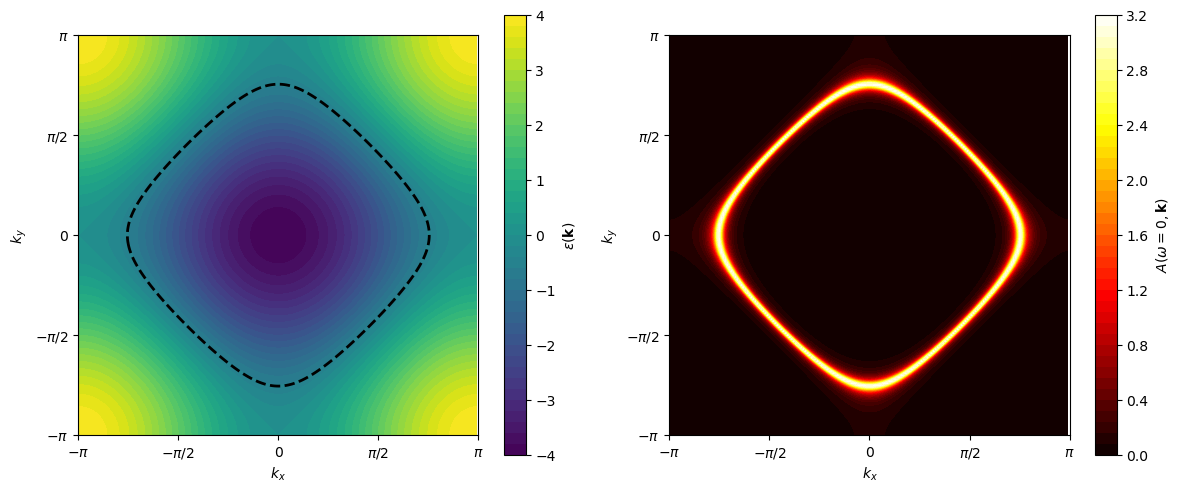

In [29]:
lat = LATTICE(dim=2)
nk = 200

lat.get_bz(nk, ibz=False)
lat.get_e_k()

kx = lat.k_vecs[:,0].reshape(nk,nk)
ky = lat.k_vecs[:,1].reshape(nk,nk)
e_k = lat.e_k.reshape(nk,nk)

kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

Gamma = 0.1
mu = get_mu(e_k=lat.e_k, n_goal=0.75, beta=1/0.01)
A_k0 = (1/np.pi) * Gamma / (Gamma**2 + (e_k - mu)**2)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cf = axs[0].contourf(kx, ky, e_k, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

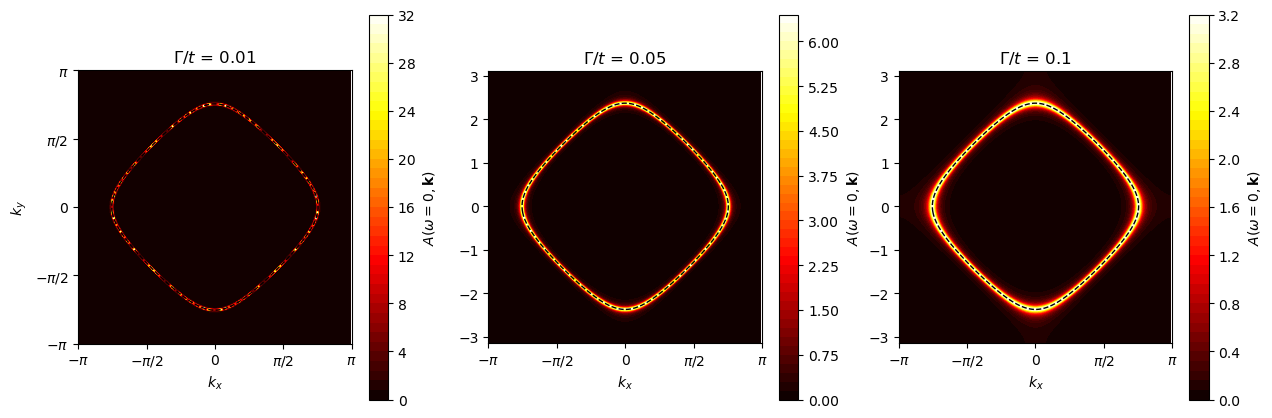

In [38]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

Gamma_list = [0.01, 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    lat = LATTICE(dim=2)
    nk = 200

    lat.get_bz(nk, ibz=False)
    lat.get_e_k()

    kx = lat.k_vecs[:,0].reshape(nk,nk)
    ky = lat.k_vecs[:,1].reshape(nk,nk)
    e_k = lat.e_k.reshape(nk,nk)

    kx -= np.pi
    ky -= np.pi
    e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

    T = 0.01
    mu = get_mu(e_k=lat.e_k, n_goal=0.75, beta=1/0.01)
    A_k0 = (1/np.pi) * Gamma / (Gamma**2 + (e_k - mu)**2)

    cf = axs[i].contourf(kx, ky, A_k0, levels=50, cmap='hot')
    plt.colorbar(cf, ax=axs[i], label=r'$A(\omega=0, \mathbf{k})$')
    axs[i].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=1)

    axs[i].set_title(f"$\Gamma/t$ = {Gamma}")

    axs[i].set_xlabel(r'$k_x$')
    axs[i].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    axs[i].set_aspect('equal')

axs[0].set_ylabel(r'$k_y$')
axs[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

plt.show()

Gamma =  0.1


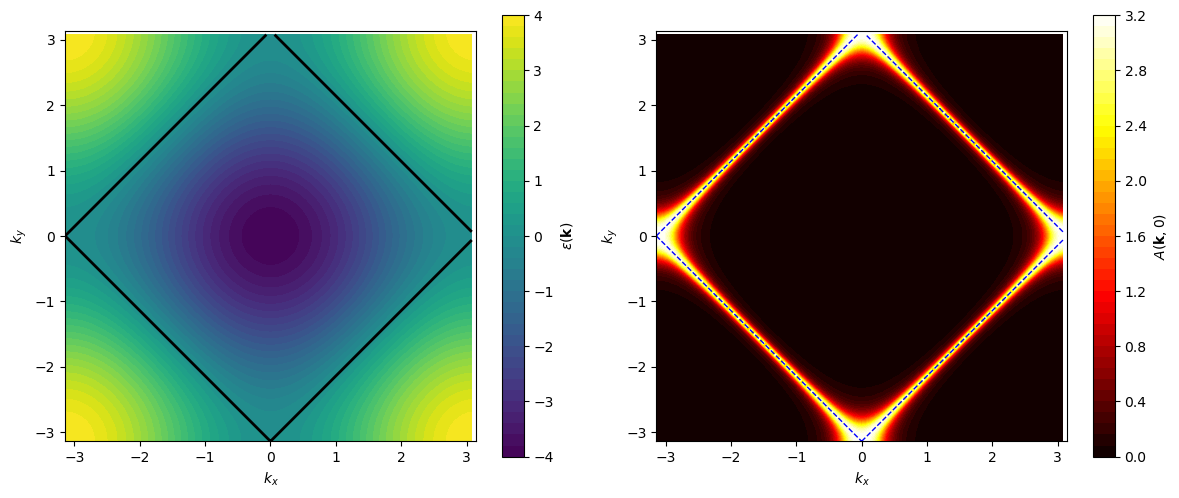

In [2]:
square = LATTICE(dim=2, tp=0.)
nk = 100

square.get_e_k(nk)
eps = square.e_k.data[:, 0, 0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi


v = 1
rho = dos(square.H_r.tb, nk, n_eps=100, name='')[0]
rho_0 = np.interp(0.0, rho.eps, rho.rho)
Gamma = np.pi * v**2 * rho_0
Gamma = 0.1
print('Gamma = ', Gamma)

T = 0.1
n = 1
mu = get_mu(e_k=square.e_k, n_goal=n, beta=1/T)
Ak0 = (1/np.pi) * Gamma / (Gamma**2 + (eps - mu)**2)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
cf = ax.contourf(kx, ky, eps, levels=50)
plt.colorbar(cf, ax=ax, label=r'$\varepsilon(\mathbf{k})$')
ax.contour(kx, ky, eps, levels=[mu], colors='black', linewidths=2)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

ax = axes[1]
cf2 = ax.contourf(kx, ky, Ak0, levels=50, cmap='hot')
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

Starting serial run at: 2026-06-08 02:28:23.482725
Starting serial run at: 2026-06-08 02:28:23.486086
Starting serial run at: 2026-06-08 02:28:23.604516
Starting serial run at: 2026-06-08 02:28:23.614709
Starting serial run at: 2026-06-08 02:28:23.625713


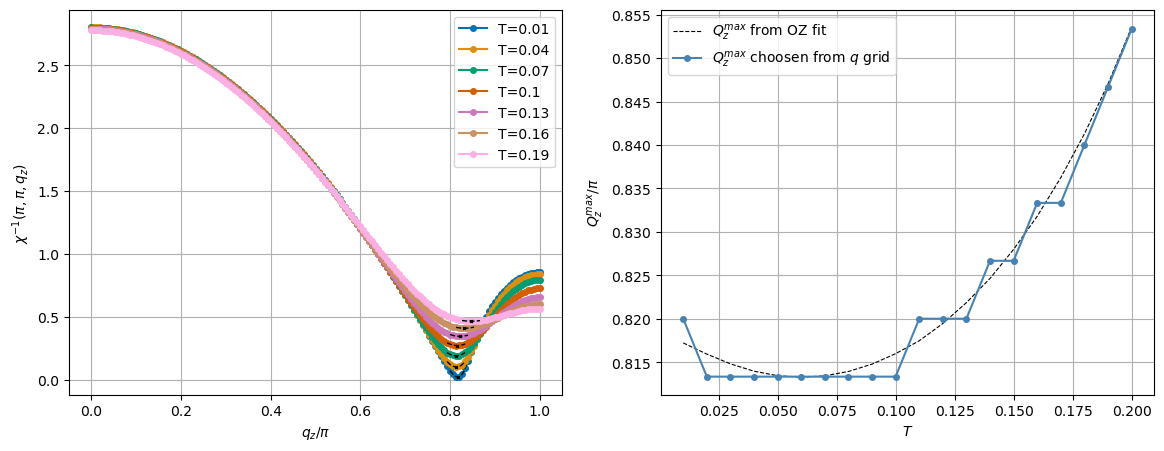

In [ ]:
n = 0.847
T_list = np.linspace(0.01, 0.2, 20)
U = 3

nk = 300
lat = LATTICE()
initialize_bz(lat, nk, refine=False, ibz=True)

inputs = [{'lat': lat, 'niw': 256, 'S_val': -1j*0.05, 'get_xi': True, 'xi_range': [0,0,2e-2],'verbose': False, 'save_invchigrid': True, 'par': {'U': U, 'n': n, 'T': T}} for T in T_list]

results_list = run_parallel(run_rpa, inputs, workers=5)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
    fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z/\pi$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q^{max}_z/\pi$')

q_path = ([1,1,0],[1,1,1])
q_grid, path_mesh = get_grid_from_path(q_path, lat.k_vecs)
qz_grid = q_grid[:,-1]
Qz = []
Qz_ref = []
Qz_fit = []
for i, data in enumerate(results_list):
    
    invchi_grid_path = data['invchi_grid'][path_mesh]
    Qz.append(qz_grid[np.argmin(invchi_grid_path)])
    Qz_fit.append(data['Q'][-1])
    plot_every = 3
    if i%plot_every == 0:
        ax[0].plot(qz_grid, invchi_grid_path, 'o-', markersize=2, label=f'T={T_list[i]:.4g}', color=color_list[i//plot_every])

        qz_grid_fitted = np.linspace(Qz[-1]-data['xi_range'][-1], Qz[-1]+data['xi_range'][-1], data['xi_pts'])
        OZ_curve = [1/OZ(qz, *data['OZ_fit']) for qz in qz_grid_fitted]
        ax[0].plot(qz_grid_fitted, OZ_curve, '--', color='black', linewidth=1)
        ax[0].plot(Qz_fit[-1], data['invchi'], 'x', markersize=4, color='black')

ax[1].plot(T_list, Qz_fit, '--', color='black', linewidth=0.8, label='$Q_z^{max}$ from OZ fit')
ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue', label='$Q_z^{max}$ choosen from $q$ grid')

for a in ax:
    a.grid()
    a.legend()
plt.show()

Starting serial run at: 2026-06-08 04:28:11.125248
Starting serial run at: 2026-06-08 04:28:11.203692
Starting serial run at: 2026-06-08 04:28:11.276961
Starting serial run at: 2026-06-08 04:28:11.320957


Starting serial run at: 2026-06-08 04:28:11.361730


n: 0.845, U: 3.000: Completed 15 jobs in 682.6 seconds
n: 0.846, U: 3.000: Completed 15 jobs in 674.4 seconds
n: 0.847, U: 3.000: Completed 15 jobs in 675.1 seconds
n: 0.848, U: 3.000: Completed 15 jobs in 672.9 seconds
n: 0.849, U: 3.000: Completed 15 jobs in 672.1 seconds
n: 0.850, U: 3.000: Completed 15 jobs in 668.6 seconds
n = 0.845 :
 chi: gamma = 1.654, Tc = -0.100, xi: nu = 1.505, Tc = -0.092
n = 0.846 :
 chi: gamma = 1.500, Tc = -0.064, xi: nu = 1.329, Tc = -0.056
n = 0.847 :
 chi: gamma = 1.171, Tc = -0.011, xi: nu = 1.117, Tc = -0.022
n = 0.848 :
 chi: gamma = 0.713, Tc = 0.006, xi: nu = 0.718, Tc = 0.001
n = 0.849 :
 chi: gamma = 0.730, Tc = 0.008, xi: nu = 0.513, Tc = 0.002
n = 0.85 :
 chi: gamma = 1.056, Tc = 0.025, xi: nu = 0.402, Tc = 0.002


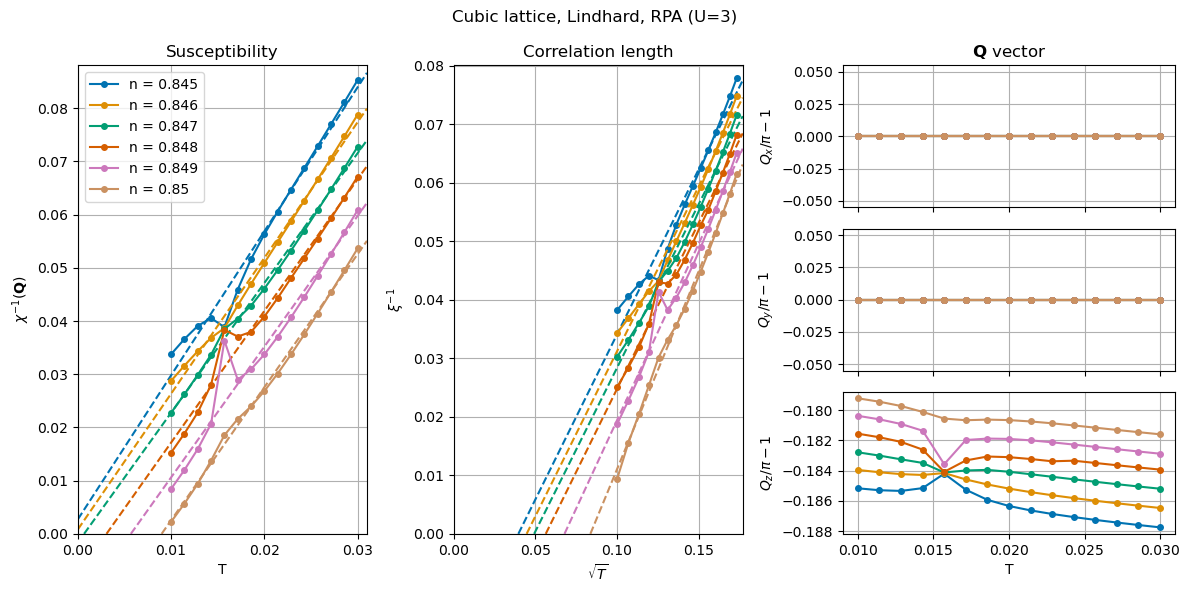

In [2]:
U = 3
n_list = np.linspace(0.845, 0.85, 6)
T_list = np.linspace(0.01, 0.03, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE()
initialize_bz(lat, nk=300, refine=False, ibz=True)

Gamma = 0.05
niw = 256
results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, niw=niw, S_list=-1j*Gamma, get_xi=True, xi_range=[0,0,2e-2], fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(1,0.5), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    for ax in axs[:2]:
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

plt.show()

In [2]:
U = 3
n_list = np.linspace(0.855, 0.86, 6)
T_list = np.linspace(0.02, 0.04, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 100
lat = LATTICE()
initialize_bz(lat, nk=nk, refine=False, ibz=True)

v = 0.1
niw = 256
results_list = []
scba = SCBA(lat, niw, nk)
for n in n_list:
    inputs = [{'v': v, 'beta': 1/T, 'n_goal': n, 'verbose': True} for T in T_list]
    S_list = run_parallel(scba.run, inputs, workers=5)

    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, niw=niw, S_list=S_list, get_xi=True, xi_range=[0,0,2e-2], fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    for ax in axs[:2]:
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

plt.show()

SCBA: nk=100^3, niw=256, T=0.02, mu=0.0000, v=0.100
SCBA: nk=100^3, niw=256, T=0.02, mu=0.0000, v=0.100


Starting serial run at: 2026-06-08 08:56:22.798306
Starting serial run at: 2026-06-08 08:56:22.804487
Starting serial run at: 2026-06-08 08:56:22.843630
Starting serial run at: 2026-06-08 08:56:22.905026
Starting serial run at: 2026-06-08 08:56:22.930059


SCBA: nk=100^3, niw=256, T=0.02, mu=0.0000, v=0.100
SCBA: nk=100^3, niw=256, T=0.02, mu=0.0000, v=0.100
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
Converged at step 7 with diff = 1.024e-11, mu = -6.324e-03
Converged at step 7 with diff = 8.290e-12, mu = -8.200e-03
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
Converged at step 7 with diff = 8.672e-12, mu = -7.728e-03
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
Converged at step 7 with diff = 9.112e-12, mu = -7.258e-03
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
Converged at step 7 with diff = 9.628e-12, mu = -6.790e-03
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
Converged at step 7 with diff = 7.952e-12, mu = -8.674e-03
Converged at step 7 with diff = 7.648e-12, mu = -9.150e-03
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
SCBA: nk=100^3, niw=256, T=0.04, mu=0.0000, v=0.100
Converged at step 7 with diff = 7.372e-12, mu = -9.628e-03
SCBA: nk

/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxfev=10000)
/home/ctort/Desktop/dmft/code/scripts/obs.py:532: OptimizeWarning: Covariance of the parameters could not be estimated
  par, _ = curve_fit(OZ_fit, s_grid, chi_grid, p0=p0, bounds=bounds, maxf

n: 0.855, U: 3.000: Completed 15 jobs in 24.5 seconds
SCBA: nk=100^3, niw=256, T=0.02, mu=0.0000, v=0.100
SCBA: nk=100^3, niw=256, T=0.02, mu=0.0000, v=0.100
SCBA: nk=100^3, niw=256, T=0.02, mu=0.0000, v=0.100
SCBA: nk=100^3, niw=256, T=0.02, mu=0.0000, v=0.100
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
Converged at step 7 with diff = 9.113e-12, mu = -7.211e-03
Converged at step 7 with diff = 9.629e-12, mu = -6.746e-03
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
Converged at step 7 with diff = 8.291e-12, mu = -8.147e-03
Converged at step 7 with diff = 1.025e-11, mu = -6.283e-03
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
Converged at step 7 with diff = 8.673e-12, mu = -7.678e-03
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
SCBA: nk=100^3, niw=256, T=0.03, mu=0.0000, v=0.100
Converged at step 7 with diff = 7.952e-12, mu = -8.617e-03
Converged at step 7 with diff = 7.648e-12, mu = -9.090e-03
SCBA: nk=100^

KeyboardInterrupt: 

n = 0.855 :
 chi: gamma = 0.813, Tc = 0.021, xi: nu = 1.546, Tc = -0.130
n = 0.856 :
 chi: gamma = 1.059, Tc = 0.019, xi: nu = 1.543, Tc = -0.130


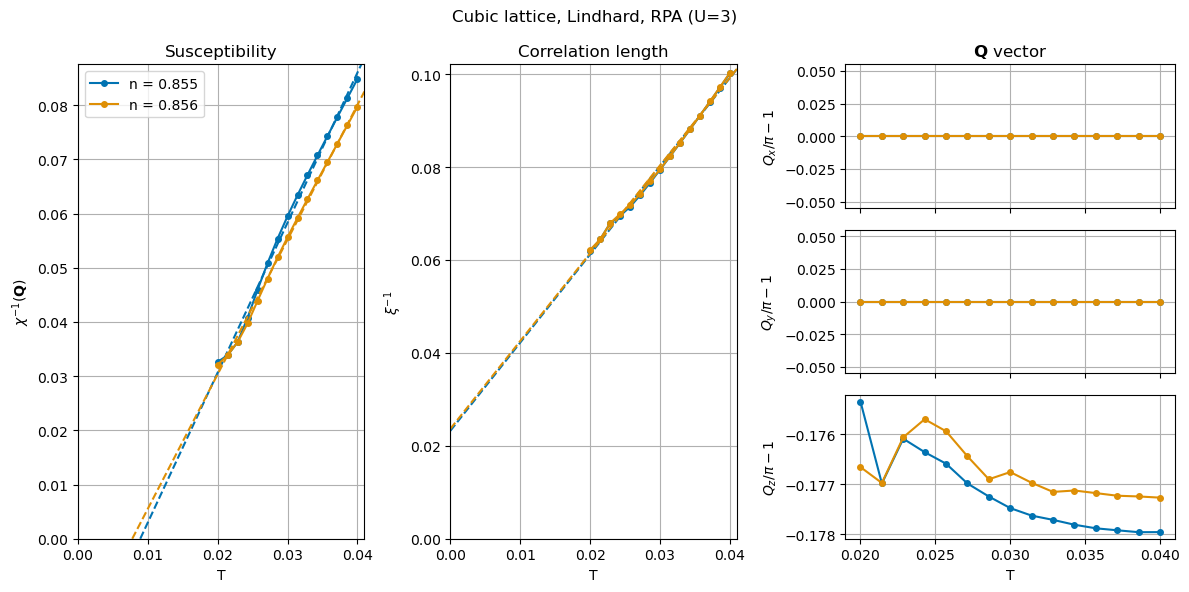

In [3]:
fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    for ax in axs[:2]:
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

plt.show()

Starting serial run at: 2026-06-08 09:24:14.669013
Starting serial run at: 2026-06-08 09:24:14.690620
Starting serial run at: 2026-06-08 09:24:14.720183
Starting serial run at: 2026-06-08 09:24:14.733919


Starting serial run at: 2026-06-08 09:24:14.898969


n: 0.845, U: 3.000: Completed 15 jobs in 84.7 seconds
n: 0.846, U: 3.000: Completed 15 jobs in 81.5 seconds
n: 0.847, U: 3.000: Completed 15 jobs in 82.1 seconds
n: 0.848, U: 3.000: Completed 15 jobs in 82.7 seconds
n: 0.849, U: 3.000: Completed 15 jobs in 82.2 seconds
n: 0.850, U: 3.000: Completed 15 jobs in 83.1 seconds
n = 0.845 :
 chi: gamma = 0.889, Tc = 0.011, xi: nu = 0.917, Tc = -0.002
n = 0.846 :
 chi: gamma = 1.072, Tc = 0.006, xi: nu = 1.038, Tc = -0.011
n = 0.847 :
 chi: gamma = 1.253, Tc = -0.014, xi: nu = 1.164, Tc = -0.026
n = 0.848 :
 chi: gamma = 1.413, Tc = -0.037, xi: nu = 1.278, Tc = -0.041
n = 0.849 :
 chi: gamma = 1.540, Tc = -0.054, xi: nu = 1.364, Tc = -0.051
n = 0.85 :
 chi: gamma = 1.632, Tc = -0.063, xi: nu = 1.411, Tc = -0.051


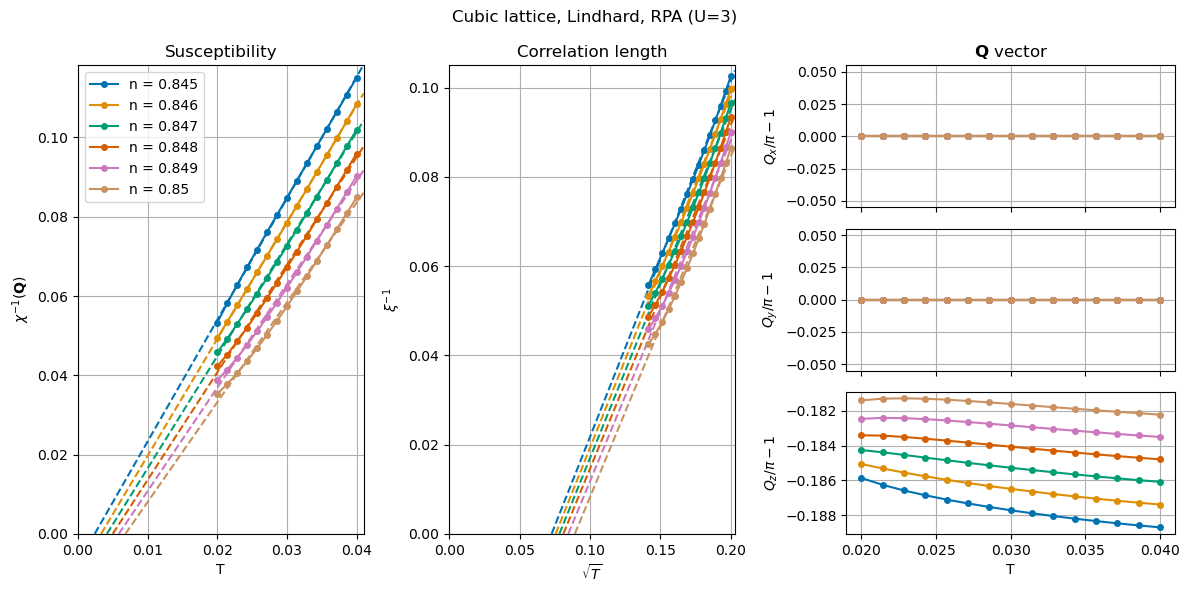

In [4]:
U = 3
n_list = np.linspace(0.845, 0.85, 6)
T_list = np.linspace(0.02, 0.04, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE()
initialize_bz(lat, nk=150, refine=False, ibz=True)

Gamma = 0.05
niw = 256
results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, niw=niw, S_list=-1j*Gamma, get_xi=True, xi_range=[0,0,2e-2], fit=True, workers=5))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=(1,0.5), fit=True,
                        title=title, label=f'n = {n:.4g}', figure=fig)
    
    _, axs = fig
    for ax in axs[:2]:
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

plt.show()

0
1
2
3
4


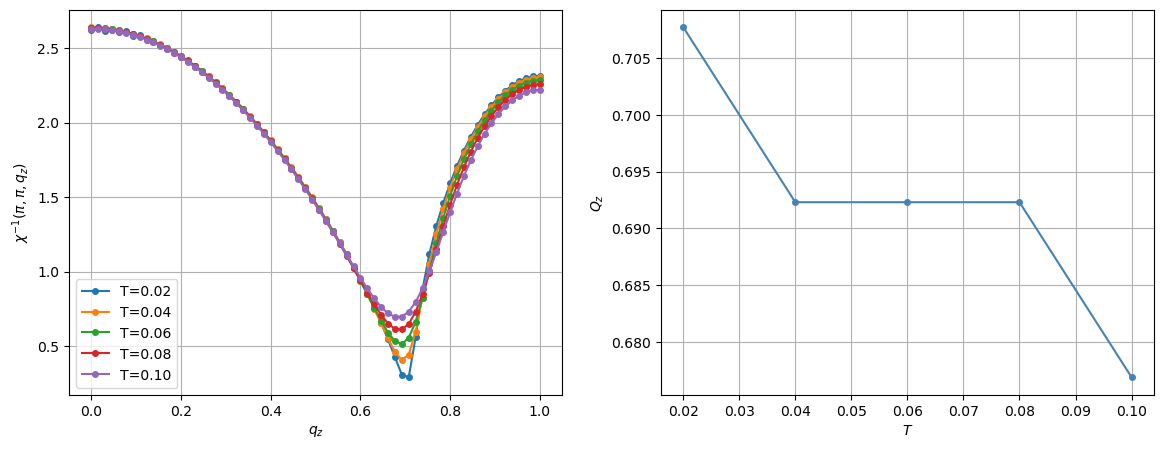

In [5]:
n = 0.75
T_list = np.linspace(0.02, 0.1, 5)
U = 3
Gamma = 0.

nk = 130
niw = 256
lat = LATTICE()
lat.get_bz(nk, ibz=False)
lat.get_e_k()
#e_k = lat.unfold_f_k(lat.e_k)
e_k = lat.e_k
S_iwk, _ = get_iwk_arr(-1.j*Gamma, nk**3, niw=niw)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
     fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z$')

Qz = []
for i, T in enumerate(T_list):
    mu = get_mu(lat.e_k, n, 1/T, S_iwk=-1.j*Gamma, ibz_w_k=lat.ibz_w_k)

    G_iwk = np.array(get_G_iwk(mu, 1/T, e_k, S_iwk, niw))
    
    invchi0_func = lambda niw: matsubara_rsp(1/T, G_iwk[:niw+1], nk)
    invchi0_grid = niw_extrapolate(invchi0_func, niw)

    #lat.fold_f_k(invchi0_grid)

    path_idx = []
    for j, k in enumerate(lat.k_vecs):
        if abs(k[0] - np.pi) < 1e-8:
            if abs(k[1] - np.pi) < 1e-8:
                if k[2] - np.pi < 1e-8:
                    path_idx.append(j)
    
    idx = np.argmin(invchi0_grid[path_idx])
    Qz.append(lat.k_vecs[path_idx][idx][-1]/np.pi)
    #if i%4 == 0:
    ax[0].plot(lat.k_vecs[path_idx][:,-1]/np.pi, invchi0_grid[path_idx]-U, 'o-', label=f'T={T:.2f}', markersize=4)
    print(i)

ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue')
ax[0].legend()

for a in ax:
    a.grid()
plt.show()

0
1
2
3
4


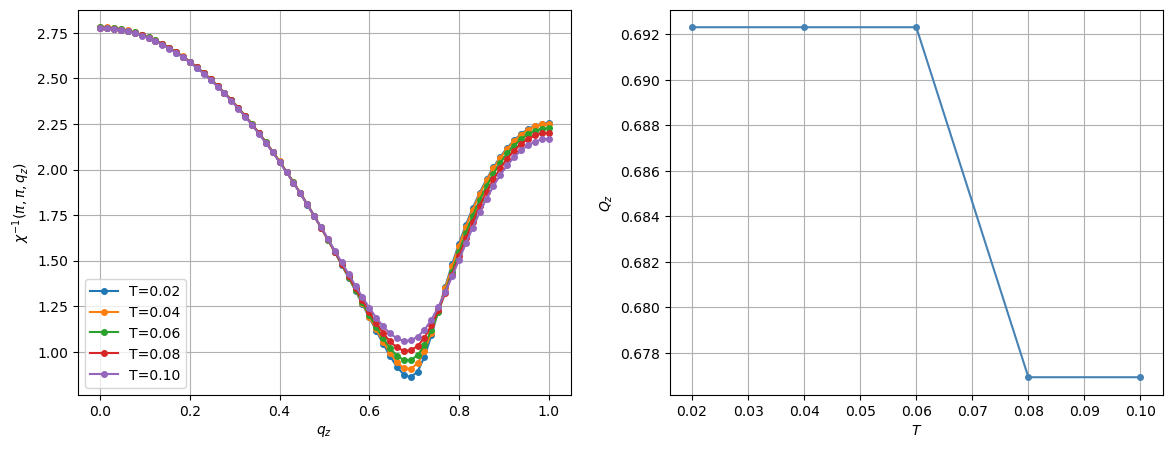

In [4]:
n = 0.75
T_list = np.linspace(0.02, 0.1, 5)
U = 3
Gamma = 0.1

nk = 130
niw = 256
lat = LATTICE()
lat.get_bz(nk, ibz=False)
lat.get_e_k()
#e_k = lat.unfold_f_k(lat.e_k)
e_k = lat.e_k
S_iwk, _ = get_iwk_arr(-1.j*Gamma, nk**3, niw=niw)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
     fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z$')

Qz = []
for i, T in enumerate(T_list):
    mu = get_mu(lat.e_k, n, 1/T, S_iwk=-1.j*Gamma, ibz_w_k=lat.ibz_w_k)

    G_iwk = np.array(get_G_iwk(mu, 1/T, e_k, S_iwk, niw))
    
    invchi0_func = lambda niw: matsubara_rsp(1/T, G_iwk[:niw+1], nk)
    invchi0_grid = niw_extrapolate(invchi0_func, niw)

    #lat.fold_f_k(invchi0_grid)

    path_idx = []
    for j, k in enumerate(lat.k_vecs):
        if abs(k[0] - np.pi) < 1e-8:
            if abs(k[1] - np.pi) < 1e-8:
                if k[2] - np.pi < 1e-8:
                    path_idx.append(j)
    
    idx = np.argmin(invchi0_grid[path_idx])
    Qz.append(lat.k_vecs[path_idx][idx][-1]/np.pi)
    #if i%4 == 0:
    ax[0].plot(lat.k_vecs[path_idx][:,-1]/np.pi, invchi0_grid[path_idx]-U, 'o-', label=f'T={T:.2f}', markersize=4)
    print(i)

ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue')
ax[0].legend()

for a in ax:
    a.grid()
plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.84, 0.86, 5)
T_list = np.linspace(0.05, 0.2, 15)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 80
niw = 256
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1j*0.1, 'method': 'matsubara', 'niw': niw, 'niw_extr': True, 'refine': True, 'refine_ratio': 2} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc = results['Xc']
    ampl = results['ampl']
    gamma = results['gamma']
    print(f"n = {n} : ampl = {ampl}, exp = {gamma}, Tc = {Tc}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), x_exp=1., fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[1]/fit[0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

In [2]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0.1, 0.3, 10)

nk = 15

Gamma_list = [0., 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')

    par_list = []
    for j, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[j], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 
                   'S_iwk_list': [1j*Gamma_list[i] for _ in T_list]} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=1, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

: 

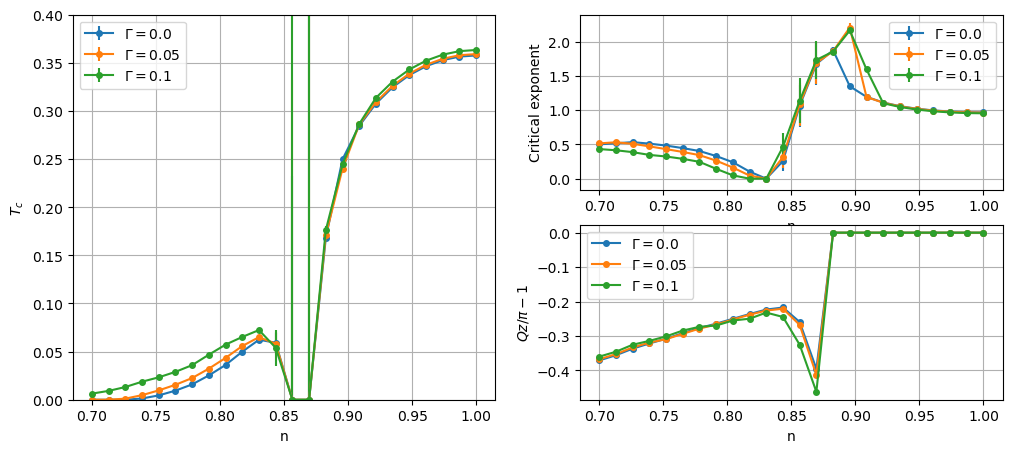

In [6]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

Gamma_list = [0., 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"$\Gamma={Gamma}$", markersize=4)

    color = line[0].get_color()
    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

    for a in ax:
        a.legend()

plt.show()

In [38]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.05, 6)

nk = 100

Gamma = 0.025
tp_list = [0.05, 0.1]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')

    par_list = []
    for j, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[j], 0.005)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 'tp': tp,
                   'S_iwk_list': [1j*Gamma for _ in T_list]} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
Starting serial run at: 2026-04-27 11:32:19.460754
Starting serial run at: 2026-04-27 11:32:19.460862
Starting serial run at: 2026-04-27 11:32:19.476135


Starting serial run at: 2026-04-27 11:32:19.517090
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  5.5min


Starting serial run at: 2026-04-27 11:37:48.664854


Starting serial run at: 2026-04-27 11:37:49.502659
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  5.8min


Starting serial run at: 2026-04-27 11:43:46.625501


...

Starting serial run at: 2026-04-27 12:07:12.018905


Starting serial run at: 2026-04-27 12:07:24.946133


Starting serial run at: 2026-04-27 12:07:25.619399
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 17.2min


Starting serial run at: 2026-04-27 12:12:50.348300
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed: 17.7min remaining:  8.9min


Starting serial run at: 2026-04-27 12:13:25.034416
[Parallel(n_jobs=6)]: Done  19 out of  24 | elapsed: 23.3min remaining:  6.1min
[Parallel(n_jobs=6)]: Done  22 out of  24 | elapsed: 23.5min remaining:  2.1min
[Parallel(n_jobs=6)]: Done  24 out of  24 | elapsed: 23.6min finished


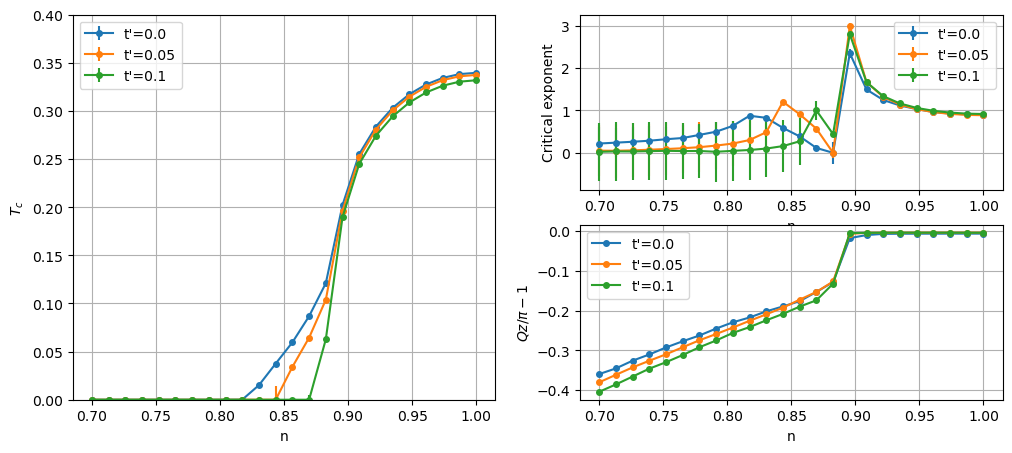

In [40]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(-0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

Gamma = 0.025
tp_list = [0., 0.05, 0.1]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"t'={tp}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()


plt.savefig(f'{save_dir}/g{Gamma:.3f}postp.png', dpi=100)
plt.show()

SCBA: nk=100^2, beta=10.00, mu=0.0000, scatt. pot.=1.000
Converged at step 15 with diff = 4.495e-11
0.538182094297202


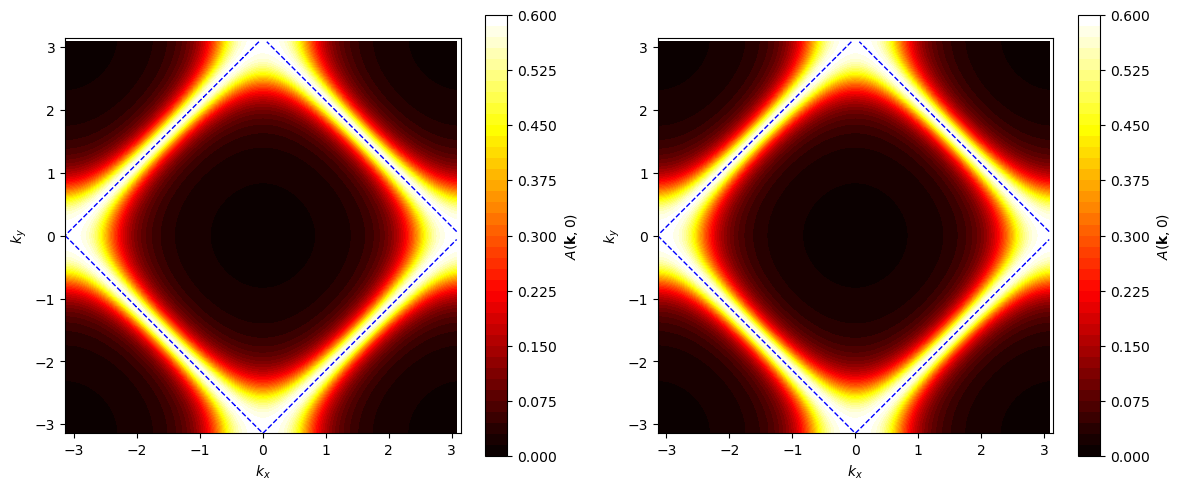

In [142]:
square = LATTICE(dim=2)
nk = 100

square.get_e_k(nk)
eps = square.e_k.data[:,0,0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.1
n = 1
mu = get_mu(square.e_k, n, 1/T)
v = 1.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

square.get_e_k(nk=nk)
scba = SCBA(square, 1/T, nk=nk)
scba.run(v=v, n_goal=n, constant=True)
A1 = get_A_iw0k(scba.G_iwk).reshape(nk, nk)

S_iw = GfImFreq(beta=1/T, statistic='Fermion', n_points=scba.n_iw, target_shape=[1,1])
S_iw.data[:, 0, 0] = scba.S_iwk.data[:, :, 0, 0].mean(axis=1)

# Pade continue to real axis at omega=0
w_mesh = MeshReFreq(w_min=0.0, w_max=0.0, n_w=1)
S_w = GfReFreq(mesh=w_mesh, target_shape=[1,1])
S_w.set_from_pade(S_iw, n_points=60)

Gamma_eff = -S_w.data[0, 0, 0].imag
print(Gamma_eff)

A2 = (1/np.pi) * Gamma_eff / (Gamma_eff**2 + (eps - mu)**2)

vmax = max(A1.max(), A2.max())
vmin = min(A1.min(), A2.min())

ax = axes[0]
cf1 = axes[0].contourf(kx, ky, A1, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf1, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

ax = axes[1]
cf2 = axes[1].contourf(kx, ky, A2, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

SCBA: nk=100^2, beta=10.00, mu=0.0000, scatt. pot.=1.000
Converged at step 11 with diff = 4.054e-11
0.1379977548712244


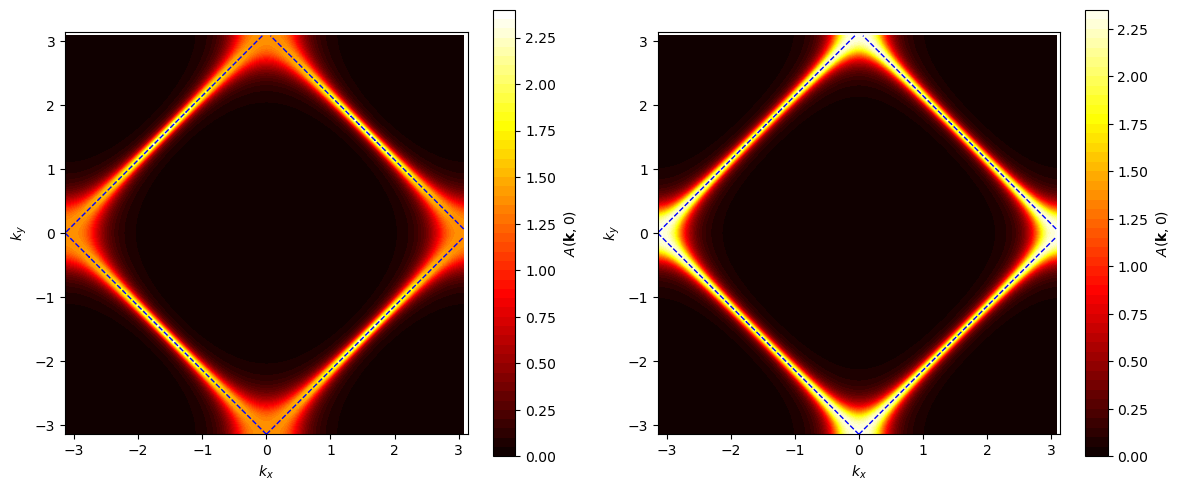

In [143]:
square = LATTICE(dim=2)
nk = 100

square.get_e_k(nk)
eps = square.e_k.data[:,0,0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.1
n = 1
mu = get_mu(square.e_k, n, 1/T)
v = 1.
xi = 0.2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

square.get_e_k(nk=nk)
scba = SCBA(square, 1/T, xi=xi, nk=nk)
scba.run(v=v, n_goal=n, constant=False)
A1 = get_A_iw0k(scba.G_iwk).reshape(nk, nk)

S_iw = GfImFreq(beta=1/T, statistic='Fermion', n_points=scba.n_iw, target_shape=[1,1])
S_iw.data[:,0,0] = scba.S_iwk.data[:,:,0,0].mean(axis=1)

# Pade continue to real axis at omega=0
w_mesh = MeshReFreq(w_min=0.0, w_max=0.0, n_w=1)
S_w = GfReFreq(mesh=w_mesh, target_shape=[1,1])
S_w.set_from_pade(S_iw, n_points=60)

Gamma_eff = -S_w.data[0,0,0].imag
print(Gamma_eff)

A2 = (1/np.pi) * Gamma_eff / (Gamma_eff**2 + (eps - mu)**2)

vmax = max(A1.max(), A2.max())
vmin = min(A1.min(), A2.min())

ax = axes[0]
cf1 = axes[0].contourf(kx, ky, A1, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf1, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

ax = axes[1]
cf2 = axes[1].contourf(kx, ky, A2, levels=50, cmap='hot', vmax=vmax, vmin=vmin)
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
ax.contour(kx, ky, eps, levels=[mu], colors='blue', linewidths=1, linestyles='--')
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()